# Notebook 1: 

**CTA200H | Machine Learning and Computational Imaging**

---

## What is Machine Learning?

Machine learning is a broad field. It powers everything from galaxy classification to protein folding to agentic tools. But underneath all of it is a simple idea:

You have a model with adjustable parameters. You have data. You let the data tell you what the parameters should be.

$$\theta^* = \arg\min_\theta \; \mathcal{L}(\theta)$$

That's optimization and if you've done chi-squared fitting, maximum likelihood, or Bayesian MAP inference, you've already done ML. What makes modern ML powerful is:

1. **Flexible models** — neural networks can represent functions we couldn't write down analytically
2. **Automatic differentiation** — tools like JAX compute exact gradients of *any* function, making optimization tractable for millions of parameters
3. **Architecture as prior** — the structure of the model itself encodes assumptions (a small network can only represent smooth functions, acting as a built-in regularizer)

In this lecture, we'll focus on the flavor of ML most connected to computational imaging, reconstructing images from incomplete data using forward models and optimization. No labeled training data. But the same tools (JAX, gradient descent, neural networks) power the rest of ML too.

---

### The Recipe

Every problem in this lecture follows the same four steps:

| Step | What | Example |
|------|------|---------|
| **1. Model** | A function with adjustable parameters $\theta$ | Polynomial, pixel array, neural network |
| **2. Loss** | A number measuring how wrong the model is | $\mathcal{L}(\theta) = \sum(f_\theta(x_i) - y_i)^2$ |
| **3. Gradient** | Which direction to adjust each parameter | $\nabla_\theta \mathcal{L}$ (computed automatically!) |
| **4. Update** | Take a step downhill | $\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$ |

---

## Section 1: A Simple Problem: Fitting a Curve

### The Data

Suppose we measured some physical process and got noisy observations. Let's generate some synthetic data from a sine wave with Gaussian noise:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=300
plt.rcParams["xtick.direction"]="out"
plt.rcParams["ytick.direction"]="out"
plt.rcParams['font.family'] = 'sans-serif'

%matplotlib inline

np.random.seed(42)
x_data = np.linspace(0, 2*np.pi, 30)
y_data = np.sin(x_data) + 0.3 * np.random.randn(30)

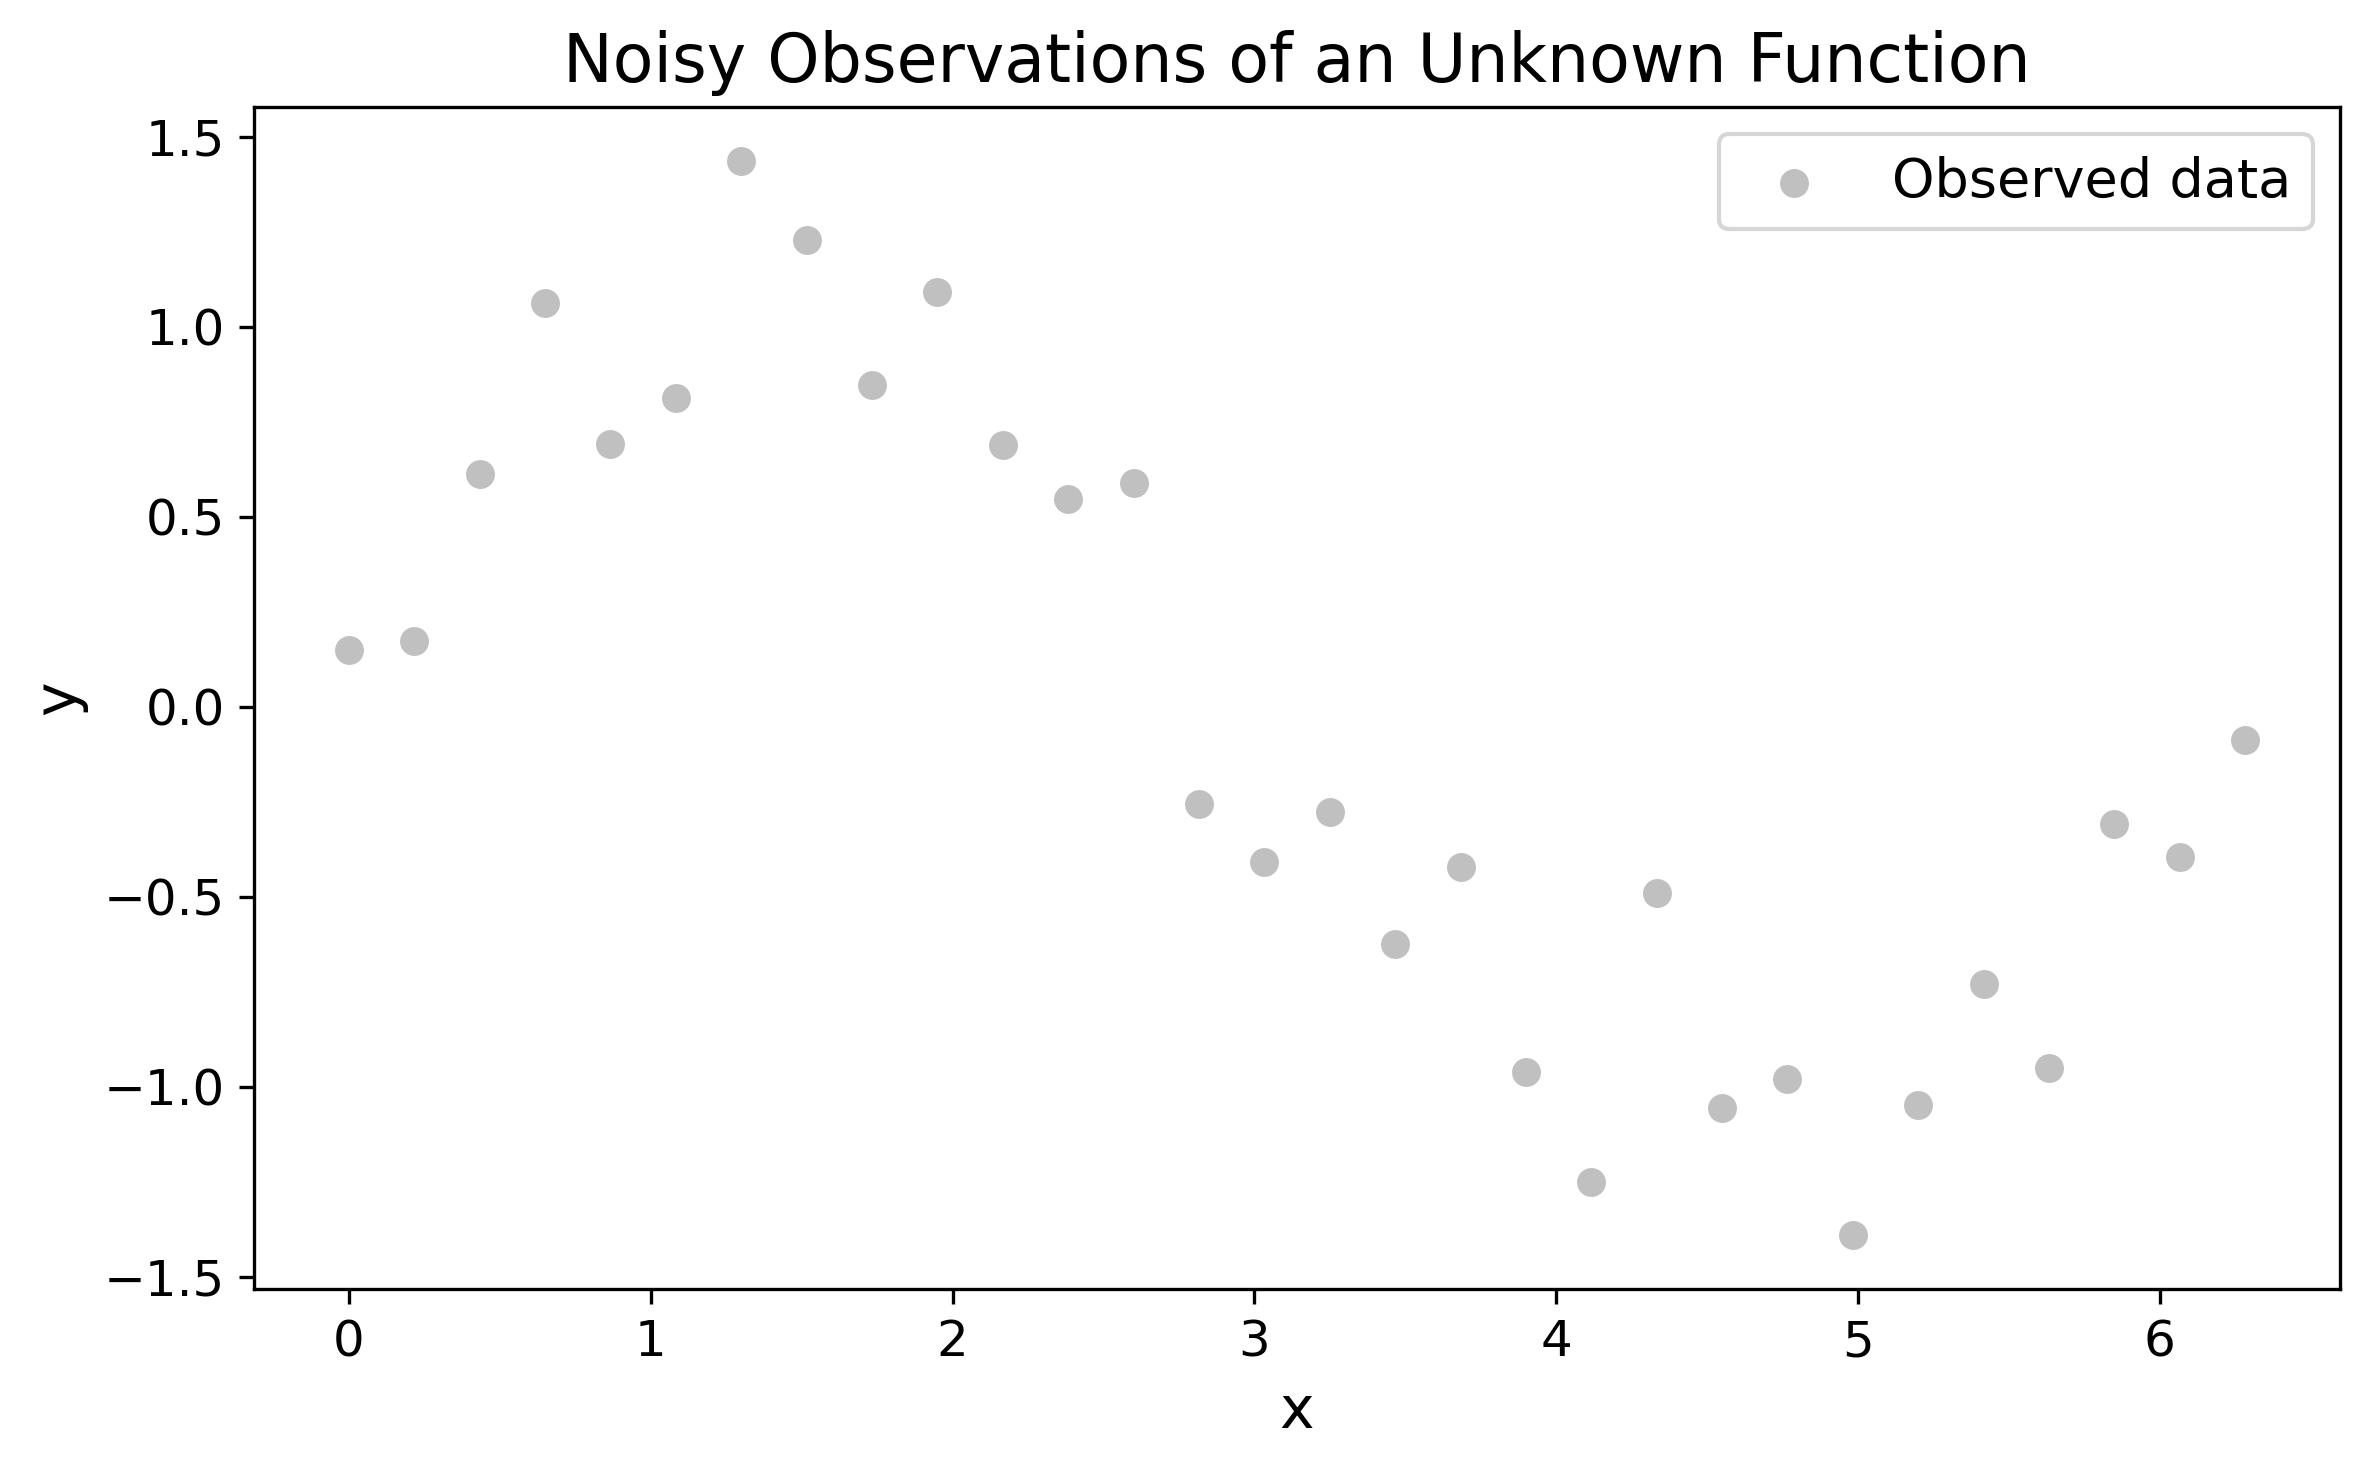

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_data, y_data, color='silver', s=60, edgecolors='white',
           linewidth=0.8, zorder=5, label='Observed data')
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_title('Noisy Observations of an Unknown Function', fontsize=16)
ax.tick_params(labelsize=12)
ax.legend(fontsize=13)
fig.tight_layout()
plt.show()

We can *see* a pattern in the data, but we don't know the exact function that generated it. Our goal: find a function that fits these points well.

This is exactly the kind of problem ML solves. We need our three ingredients.

---

### The Model

We need a flexible function, one with adjustable "knobs" (parameters) that we can tune to fit the data. Let's try a **polynomial**:

$$f_\theta(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$$

Here $\theta = (\theta_0, \theta_1, \theta_2, \theta_3)$ are our four parameters — the "knobs" of the model.

**The core idea of ML: we don't choose the parameter values by hand. We let the data tell us what they should be.**

But how does the data "tell us"? We need a way to measure how wrong a given set of parameters is.

---

### The Loss Function

The **loss function** measures how far our model's predictions are from the actual data. The most common choice is the **mean squared error (MSE)**:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\left(f_\theta(x_i) - y_i\right)^2$$

- If $\mathcal{L} = 0$: perfect fit (every prediction equals the observation).
- If $\mathcal{L}$ is large: the model is far from the data.

**ML = finding the parameters $\theta$ that minimize $\mathcal{L}(\theta)$.**

Let's visualize what this looks like. We'll compute the loss for many different combinations of two parameters ($\theta_1$ and $\theta_2$), holding the others fixed at zero, and plot the resulting **loss landscape**:

In [3]:
def polynomial_predict(params, x):
    """Evaluate polynomial: params[0] + params[1]*x + params[2]*x^2 + ..."""
    result = np.zeros_like(x)
    for i, p in enumerate(params):
        result = result + p * x**i
    return result

def mse_loss_np(params, x, y):
    """Mean squared error."""
    pred = polynomial_predict(params, x)
    return np.mean((pred - y)**2)

# Sweep over theta_1 and theta_2, keeping theta_0 = theta_3 = 0
theta1_range = np.linspace(-2, 2, 200)
theta2_range = np.linspace(-1, 1, 200)
T1, T2 = np.meshgrid(theta1_range, theta2_range)

loss_surface = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        params_ij = np.array([0.0, T1[i, j], T2[i, j], 0.0])
        loss_surface[i, j] = mse_loss_np(params_ij, x_data, y_data)

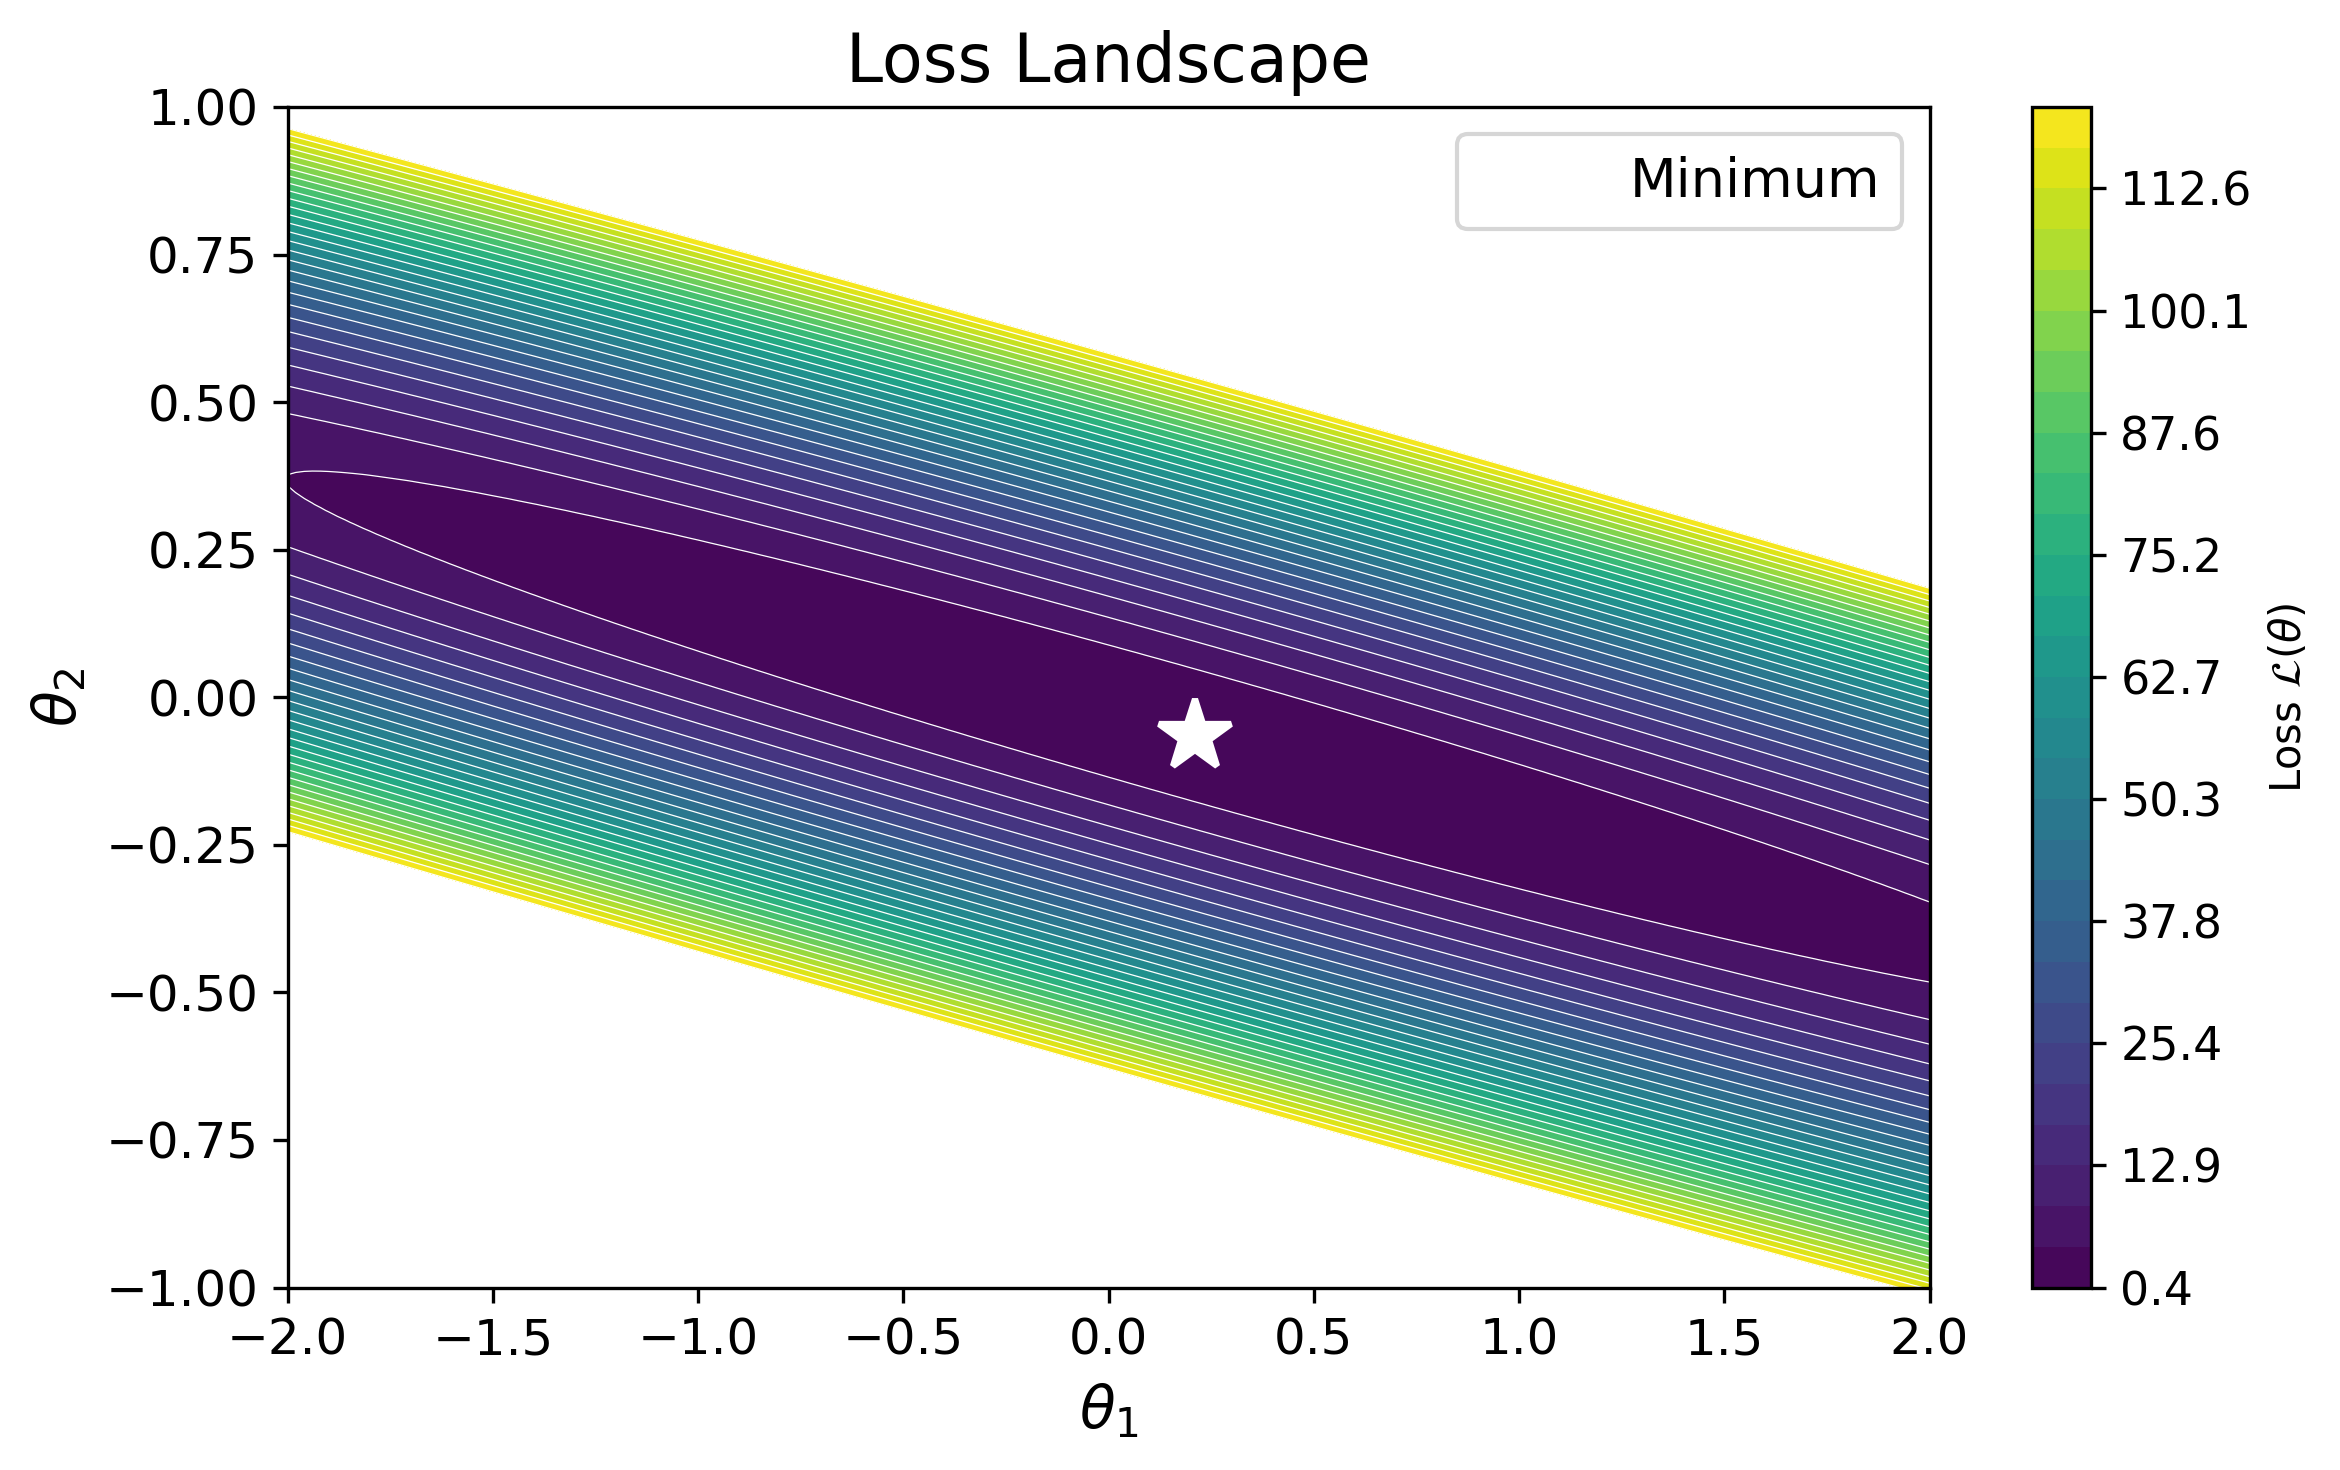

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
levels = np.linspace(loss_surface.min(), np.percentile(loss_surface, 60), 30)
cf = ax.contourf(T1, T2, loss_surface, levels=levels, cmap='viridis')
ax.contour(T1, T2, loss_surface, levels=levels, colors='white', linewidths=0.3)
cbar = fig.colorbar(cf, ax=ax, label='Loss $\mathcal{L}(\\theta)$')
cbar.ax.tick_params(labelsize=11)

# Mark the minimum
min_idx = np.unravel_index(np.argmin(loss_surface), loss_surface.shape)
ax.plot(T1[min_idx], T2[min_idx], marker='*', color='white', markersize=18,
        markeredgecolor='white', markeredgewidth=1.5, label='Minimum')

ax.set_xlabel(r'$\theta_1$', fontsize=14)
ax.set_ylabel(r'$\theta_2$', fontsize=14)
ax.set_title('Loss Landscape', fontsize=16)
ax.tick_params(labelsize=12)
ax.legend(fontsize=13, loc='upper right')
fig.tight_layout()
plt.show()

**What do you notice?** The loss landscape has a clear valley, a region where the loss is smallest. Our goal is to slide down into that valley and find the point at the very bottom. That point gives us the best-fit parameters.

But how do we navigate this landscape systematically?

---

### Gradient Descent

Imagine you are standing on a hilly landscape in thick fog. You can't see the bottom, but you *can* feel which way the ground slopes under your feet. The smart strategy: **take a step downhill**. Repeat.

Mathematically, the **gradient** $\nabla_\theta \mathcal{L}$ tells us the direction of steepest *ascent*. So we go the **opposite** way:

$$\theta_{t+1} = \theta_t - \alpha \, \nabla_\theta \mathcal{L}(\theta_t)$$

where $\alpha$ is the **learning rate**, how big a step we take each time.

- Too large $\alpha$: we overshoot and bounce around.
- Too small $\alpha$: we inch along painfully slowly.
- Just right: we smoothly converge to the minimum.

Let's try this by hand for our polynomial. For a polynomial model, we *can* compute the gradient analytically:

In [10]:
def mse_gradient_manual(params, x, y):
    """Manually computed gradient of the MSE loss for a polynomial model."""
    pred = polynomial_predict(params, x)
    residual = pred - y
    N = len(x)
    grad = np.zeros_like(params)
    for i in range(len(params)):
        grad[i] = (2.0 / N) * np.sum(residual * x**i)
    return grad

# Important: normalize x to [-1, 1] so that x^k stays manageable
# (without this, x^3 ~ 248 and the gradients blow up)
x_norm = 2 * (x_data - x_data.min()) / (x_data.max() - x_data.min()) - 1

# Gradient descent
params = np.zeros(4)
lr = 0.1
losses_manual = []

for step in range(2000):
    loss_val = mse_loss_np(params, x_norm, y_data)
    losses_manual.append(loss_val)
    grad = mse_gradient_manual(params, x_norm, y_data)
    params = params - lr * grad

print(f"Final loss: {losses_manual[-1]:.6f}")
print(f"Learned parameters: {params}")

Final loss: 0.056978
Learned parameters: [-0.13806828 -2.84289325  0.22907439  2.85734857]


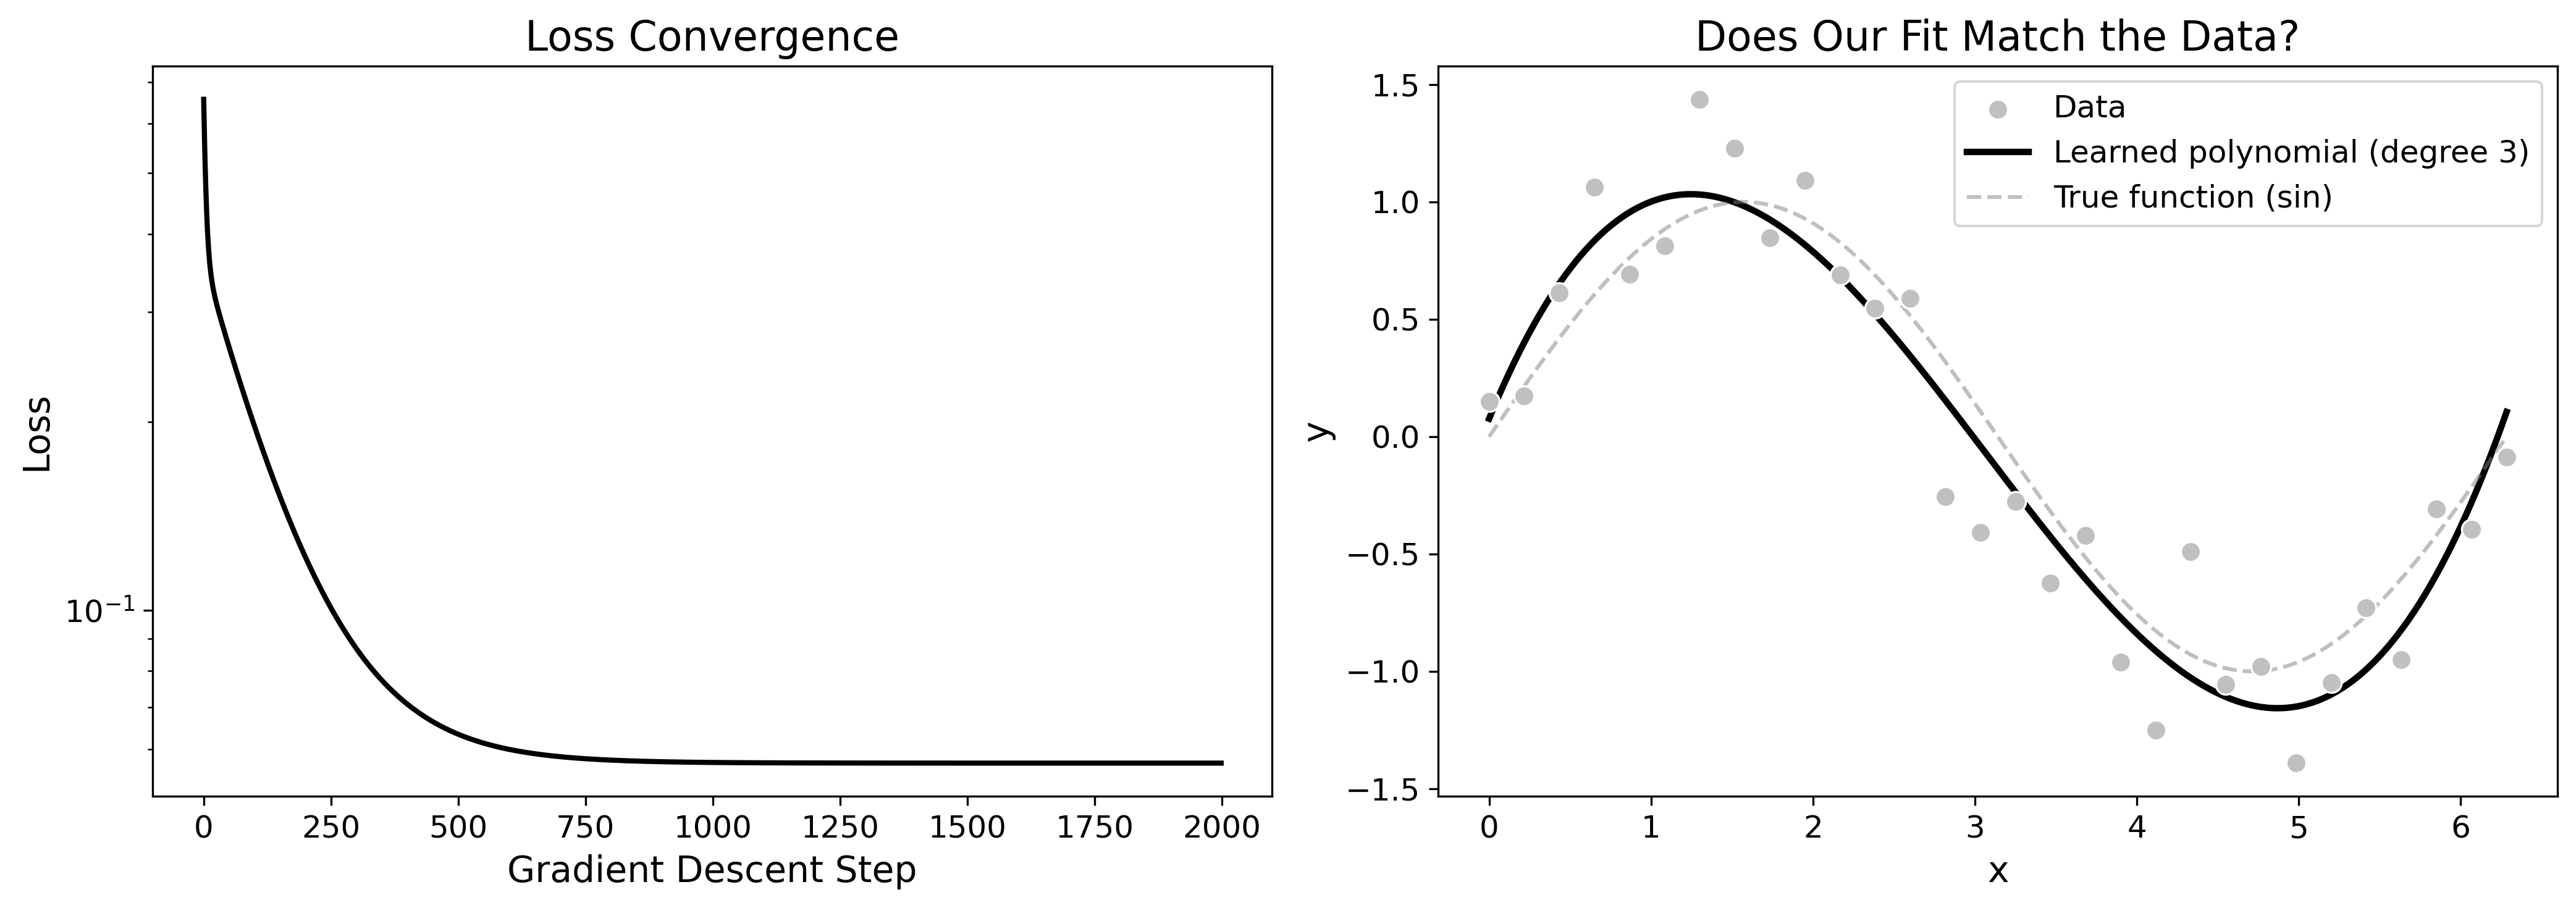

In [11]:
# Did it work? Let's see the fit and the loss curve.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss over time — is it going down?
axes[0].plot(losses_manual, color='k', linewidth=2)
axes[0].set_xlabel('Gradient Descent Step', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_title('Loss Convergence', fontsize=16)
axes[0].set_yscale('log')
axes[0].tick_params(labelsize=12)

# Right: data + the learned polynomial (evaluate on normalized x, plot on original x)
x_smooth = np.linspace(0, 2*np.pi, 200)
x_smooth_norm = 2 * (x_smooth - x_data.min()) / (x_data.max() - x_data.min()) - 1
y_fit_manual = polynomial_predict(params, x_smooth_norm)

axes[1].scatter(x_data, y_data, color='silver', s=60, edgecolors='white',
               linewidth=0.8, zorder=5, label='Data')
axes[1].plot(x_smooth, y_fit_manual, color='k', linewidth=2.5,
            label='Learned polynomial (degree 3)')
axes[1].plot(x_smooth, np.sin(x_smooth), color='gray', linewidth=1.5,
            linestyle='--', alpha=0.5, label='True function (sin)')
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('y', fontsize=14)
axes[1].set_title('Does Our Fit Match the Data?', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=12)

fig.tight_layout()
plt.show()

It works! But notice: we had to **derive the gradient formula by hand**. For a simple polynomial, that was straightforward. Each partial derivative is:

$$\frac{\partial \mathcal{L}}{\partial \theta_k} = \frac{2}{N} \sum_{i=1}^{N} \left(f_\theta(x_i) - y_i\right) \cdot x_i^k$$

But what if our model involved:

- Fourier transforms?
- Matrix inversions?
- Neural networks with millions of parameters?
- Logarithms, exponentials, and compositions of all of the above?

Deriving gradients by hand for those would be **painful, error-prone, and sometimes practically impossible**.

We need a tool that can compute gradients *automatically*, for *any* function we can write in code...

---

## Section 2: JAX  & Automatic Differentiation

### JAX = NumPy + Superpowers

[JAX](https://github.com/google/jax) is a library by Google that looks and feels almost exactly like NumPy, but adds three superpowers:

1. **`jax.grad`** : automatic differentiation (compute exact gradients of any function)
2. **`jax.jit`** : just-in-time compilation (make code run fast on CPU/GPU/TPU)
3. **`jax.vmap`** : automatic vectorization (batch operations without writing loops)

Today we will focus on the first two. Let's start with the basics.

In [12]:
import jax
import jax.numpy as jnp

# NumPy way
a_np = np.array([1., 2., 3.])
print("NumPy:", np.sum(a_np**2))

# JAX way — identical!
a_jax = jnp.array([1., 2., 3.])
print("JAX:  ", jnp.sum(a_jax**2))

NumPy: 14.0
JAX:   14.0


Almost everything you know from NumPy works the same way in JAX. There is one important difference: **JAX arrays are immutable**. You cannot modify them in place.

```python
# NumPy — this works
a_np[0] = 99

# JAX — this does NOT work
# a_jax[0] = 99       # <-- ERROR!

# JAX — do this instead
a_jax = a_jax.at[0].set(99)
```

This immutability is what makes automatic differentiation and compilation possible. Let's see some quick examples to build confidence:

In [13]:
# Meshgrid — works the same
x_grid = jnp.linspace(0, 1, 5)
y_grid = jnp.linspace(0, 1, 5)
X, Y = jnp.meshgrid(x_grid, y_grid)
print("Meshgrid shape:", X.shape)

# FFT — works the same
signal = jnp.sin(2 * jnp.pi * jnp.linspace(0, 1, 64))
spectrum = jnp.fft.fft(signal)
print("FFT output shape:", spectrum.shape)

# Immutable update
arr = jnp.zeros(5)
arr = arr.at[2].set(42.0)
print("After .at[2].set(42):", arr)

Meshgrid shape: (5, 5)
FFT output shape: (64,)
After .at[2].set(42): [ 0.  0. 42.  0.  0.]


---

### The Magic of `jax.grad`

Suppose you have *any* Python function that takes a number (or array) and returns a number. `jax.grad` gives you a **new function** that computes its derivative, automatically, exactly, at machine precision.

No calculus by hand. No finite differences. No approximations.

Let's see it in action. Consider:

$$f(x) = \sin(x) \cdot e^{-x^2}$$

Its derivative (by the product rule) is:

$$f'(x) = \cos(x) \cdot e^{-x^2} + \sin(x) \cdot (-2x) \cdot e^{-x^2}$$

Let's have JAX compute this for us:

In [14]:
def f(x):
    return jnp.sin(x) * jnp.exp(-x**2)

df = jax.grad(f)           # <-- THE MAGIC LINE
ddf = jax.grad(jax.grad(f))  # second derivative!

# Evaluate on a grid
x_plot = jnp.linspace(-3, 3, 300)
y_f   = jax.vmap(f)(x_plot)
y_df  = jax.vmap(df)(x_plot)
y_ddf = jax.vmap(ddf)(x_plot)

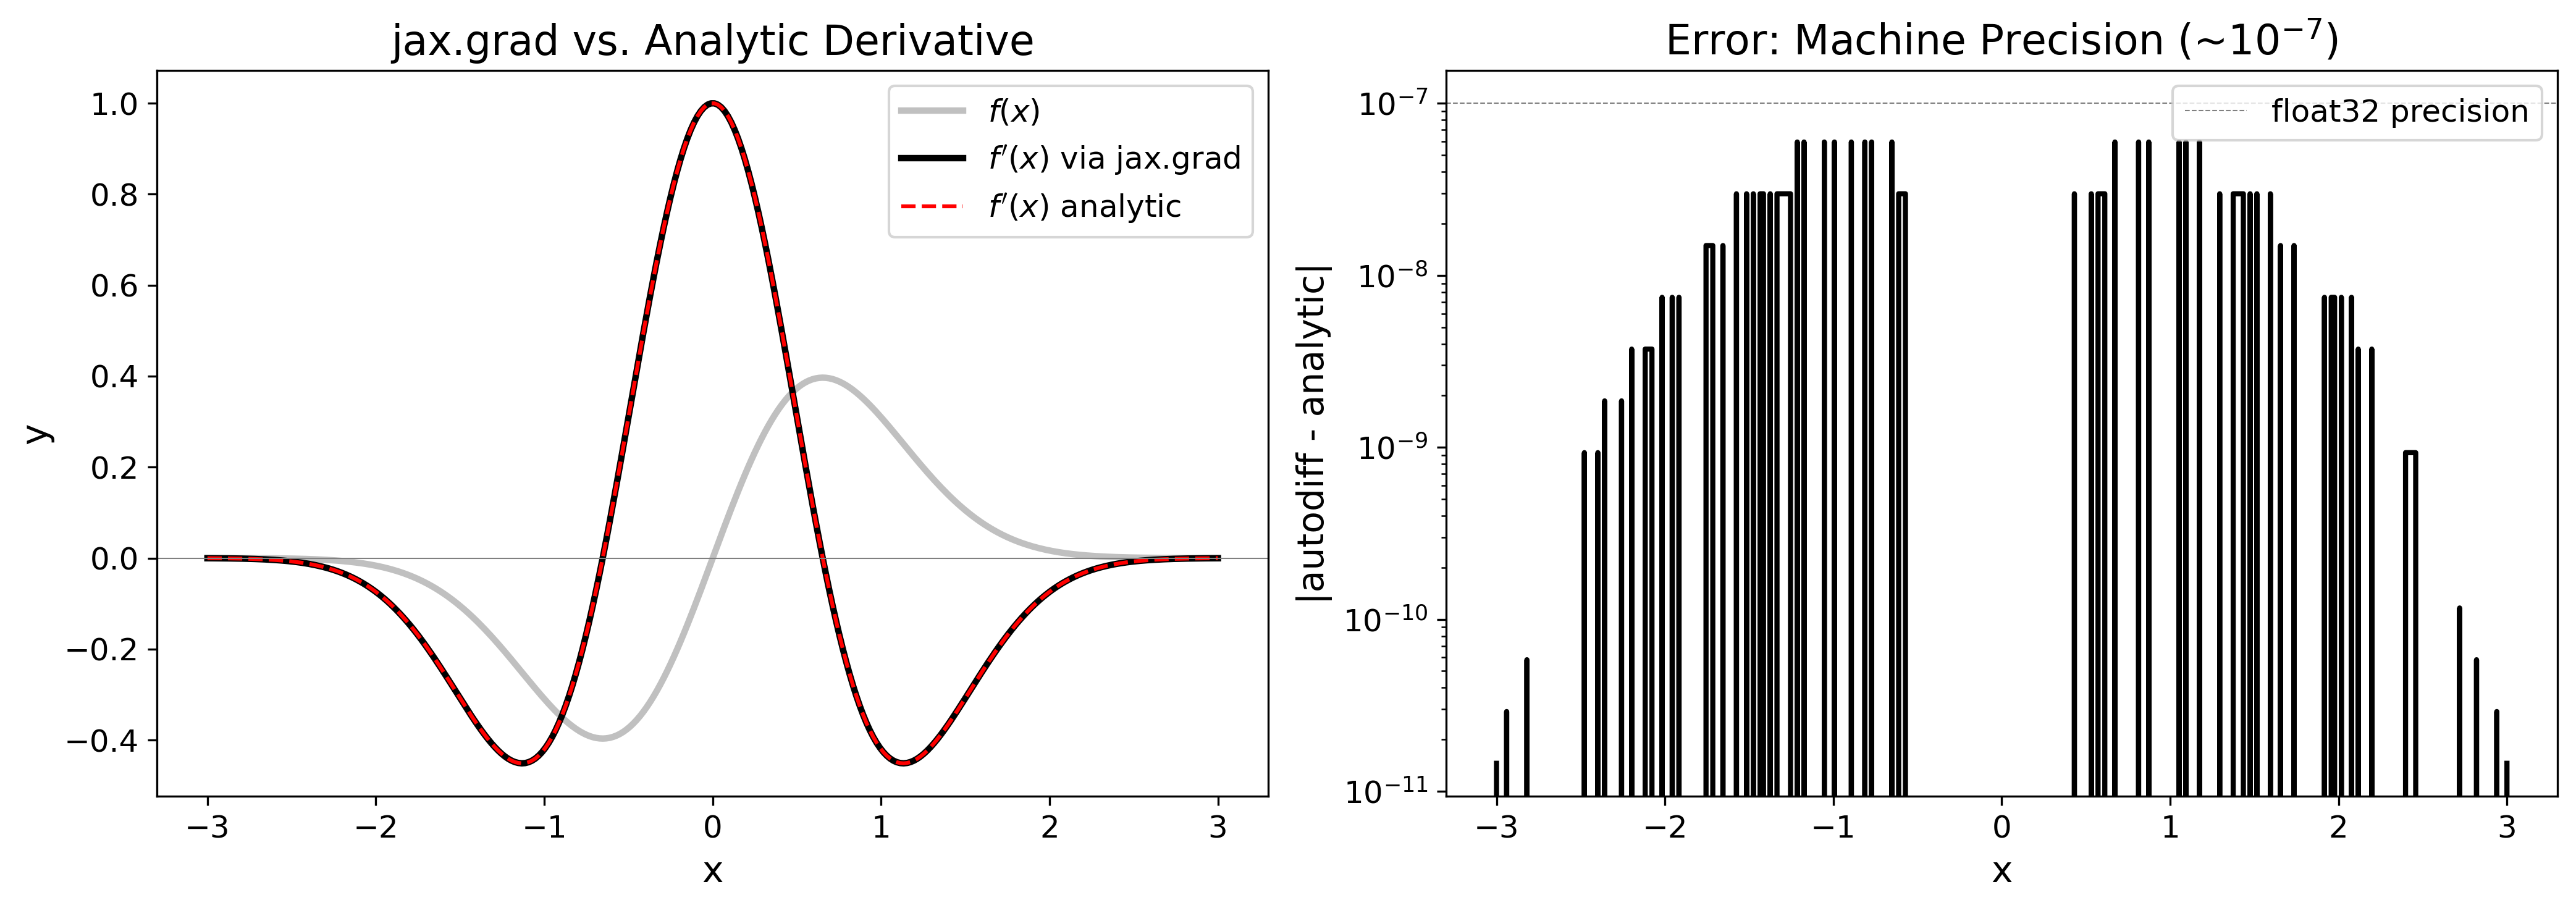

Maximum error: 5.96e-08
The error is at machine precision — jax.grad is EXACT, not approximate.


In [17]:
# Compare jax.grad with the analytic derivative we know from calculus
def df_analytic(x):
    """f'(x) = cos(x)*exp(-x^2) + sin(x)*(-2x)*exp(-x^2), by the product rule."""
    return jnp.cos(x) * jnp.exp(-x**2) + jnp.sin(x) * (-2*x) * jnp.exp(-x**2)

y_df_analytic = jax.vmap(df_analytic)(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all three curves
axes[0].plot(x_plot, y_f,  color='silver', linewidth=2.5, label=r'$f(x)$')
axes[0].plot(x_plot, y_df, color='k', linewidth=2.5, label=r"$f'(x)$ via jax.grad")
axes[0].plot(x_plot, y_df_analytic, color='r', linewidth=1.5, linestyle='--',
             label=r"$f'(x)$ analytic")
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel('x', fontsize=14)
axes[0].set_ylabel('y', fontsize=14)
axes[0].set_title('jax.grad vs. Analytic Derivative', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=12)

# Right: the difference (should be ~machine precision)
error = jnp.abs(y_df - y_df_analytic)
axes[1].semilogy(x_plot, error, color='k', linewidth=2)
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('|autodiff - analytic|', fontsize=14)
axes[1].set_title('Error: Machine Precision (~$10^{-7}$)', fontsize=16)
axes[1].tick_params(labelsize=12)
axes[1].axhline(1e-7, color='gray', linewidth=0.5, linestyle='--', label='float32 precision')
axes[1].legend(fontsize=12)

fig.tight_layout()
plt.show()

print(f"Maximum error: {float(error.max()):.2e}")
print("The error is at machine precision — jax.grad is EXACT, not approximate.")

**What do you notice?** Look at where $f'(x) = 0$, those are exactly the peaks and troughs of $f(x)$. And where $f''(x) = 0$, those are the inflection points. All computed automatically!

The key insight: **`jax.grad` works for functions of THOUSANDS of variables**, not just one. This is what makes modern machine learning possible. You write your model and loss function as ordinary Python code, and JAX figures out all the derivatives for you.

### How does `jax.grad` actually work?

You might be wondering: is `jax.grad` doing finite differences under the hood? Symbolic math like Mathematica? Neither.

There are three ways to compute derivatives:

| Method | How it works | Pros | Cons |
|--------|-------------|------|------|
| **Finite differences** | $f'(x) \approx \frac{f(x+h) - f(x)}{h}$ | Simple | Slow (one evaluation per parameter), approximate, numerically unstable |
| **Symbolic differentiation** | Apply calculus rules to produce a formula | Exact | Expressions explode in size for complex functions, can't handle loops/conditionals |
| **Automatic differentiation** | Chain rule applied to every elementary operation in your code | Exact, fast, works for *any* code | Requires a framework like JAX |

`jax.grad` uses **automatic differentiation (autodiff)**. When you call your function, JAX traces every elementary operation (add, multiply, sin, exp, ...) and builds a computational graph. Then it applies the chain rule backwards through this graph to get exact derivatives.

**Think of it this way**: your function $f$ is a composition of simple steps: $f = g_n \circ g_{n-1} \circ \cdots \circ g_1$. Each $g_i$ has a known derivative. The chain rule gives:

$$\frac{df}{dx} = \frac{dg_n}{dg_{n-1}} \cdot \frac{dg_{n-1}}{dg_{n-2}} \cdots \frac{dg_2}{dg_1} \cdot \frac{dg_1}{dx}$$

JAX computes this product **from right to left** (reverse mode). For a function with $N$ parameters, this gives all $N$ partial derivatives in a single backward pass, the same cost as one forward evaluation. This is why we can optimize models with millions of parameters.

When applied to neural networks, this backward pass through the layers is called **backpropagation**. But it's the same algorithm, chain rule on a computational graph, applied to any differentiable function, not just neural networks.

---

**Questions to think about:**

**Q: Why would finite differences be impractical for a function with 1 million parameters?**

You'd need to evaluate $f(\theta + h \cdot e_i)$ for each parameter $i$ separately, that's 1 million forward passes to get one gradient vector. Autodiff gives you all 1 million partial derivatives in a single backward pass (~1 forward pass cost).

**Q: If each elementary operation (sin, exp, multiply) has a known derivative, what does JAX need to "learn"?**

Nothing! JAX doesn't learn, it records the sequence of operations you performed and chains their known derivatives together mechanically. If you can compute it, JAX can differentiate it.

**Q: What kinds of functions *can't* be differentiated this way?**

Functions with **discontinuities** (`abs(x)` at $x=0$, hard thresholds like `if x > 0`). JAX can differentiate through conditionals by picking one branch, but the gradient won't reflect the jump. Also: integer operations, random number generators, and I/O. In practice, most physics models are smooth and this rarely matters.

---

### Back to Curve Fitting | Now with JAX

Let's redo our polynomial fit, but this time using `jax.grad` instead of a hand-derived gradient formula. We define our loss in JAX and let automatic differentiation handle the rest:

In [18]:
# Convert our data to JAX arrays
x_data_jax = jnp.array(x_data, dtype=jnp.float32)
y_data_jax = jnp.array(y_data, dtype=jnp.float32)

# Normalize x to [-1, 1] for numerical stability
x_min_val, x_max_val = float(x_data.min()), float(x_data.max())
x_norm_jax = 2 * (x_data_jax - x_min_val) / (x_max_val - x_min_val) - 1

def mse_loss(params, x, y):
    """MSE loss for a degree-3 polynomial (on normalized x)."""
    prediction = params[0] + params[1]*x + params[2]*x**2 + params[3]*x**3
    return jnp.mean((prediction - y)**2)

# jax.grad computes the gradient with respect to the FIRST argument (params)
# jax.jit compiles it for speed
grad_fn = jax.jit(jax.grad(mse_loss))

# Gradient descent
params = jnp.zeros(4)
lr = 0.1
losses = []

for step in range(2000):
    loss_val = mse_loss(params, x_norm_jax, y_data_jax)
    params = params - lr * grad_fn(params, x_norm_jax, y_data_jax)
    losses.append(float(loss_val))

print(f"Final loss: {losses[-1]:.6f}")
print(f"Learned parameters: {params}")

Final loss: 0.056978
Learned parameters: [-0.13806827 -2.842892    0.22907437  2.8573472 ]


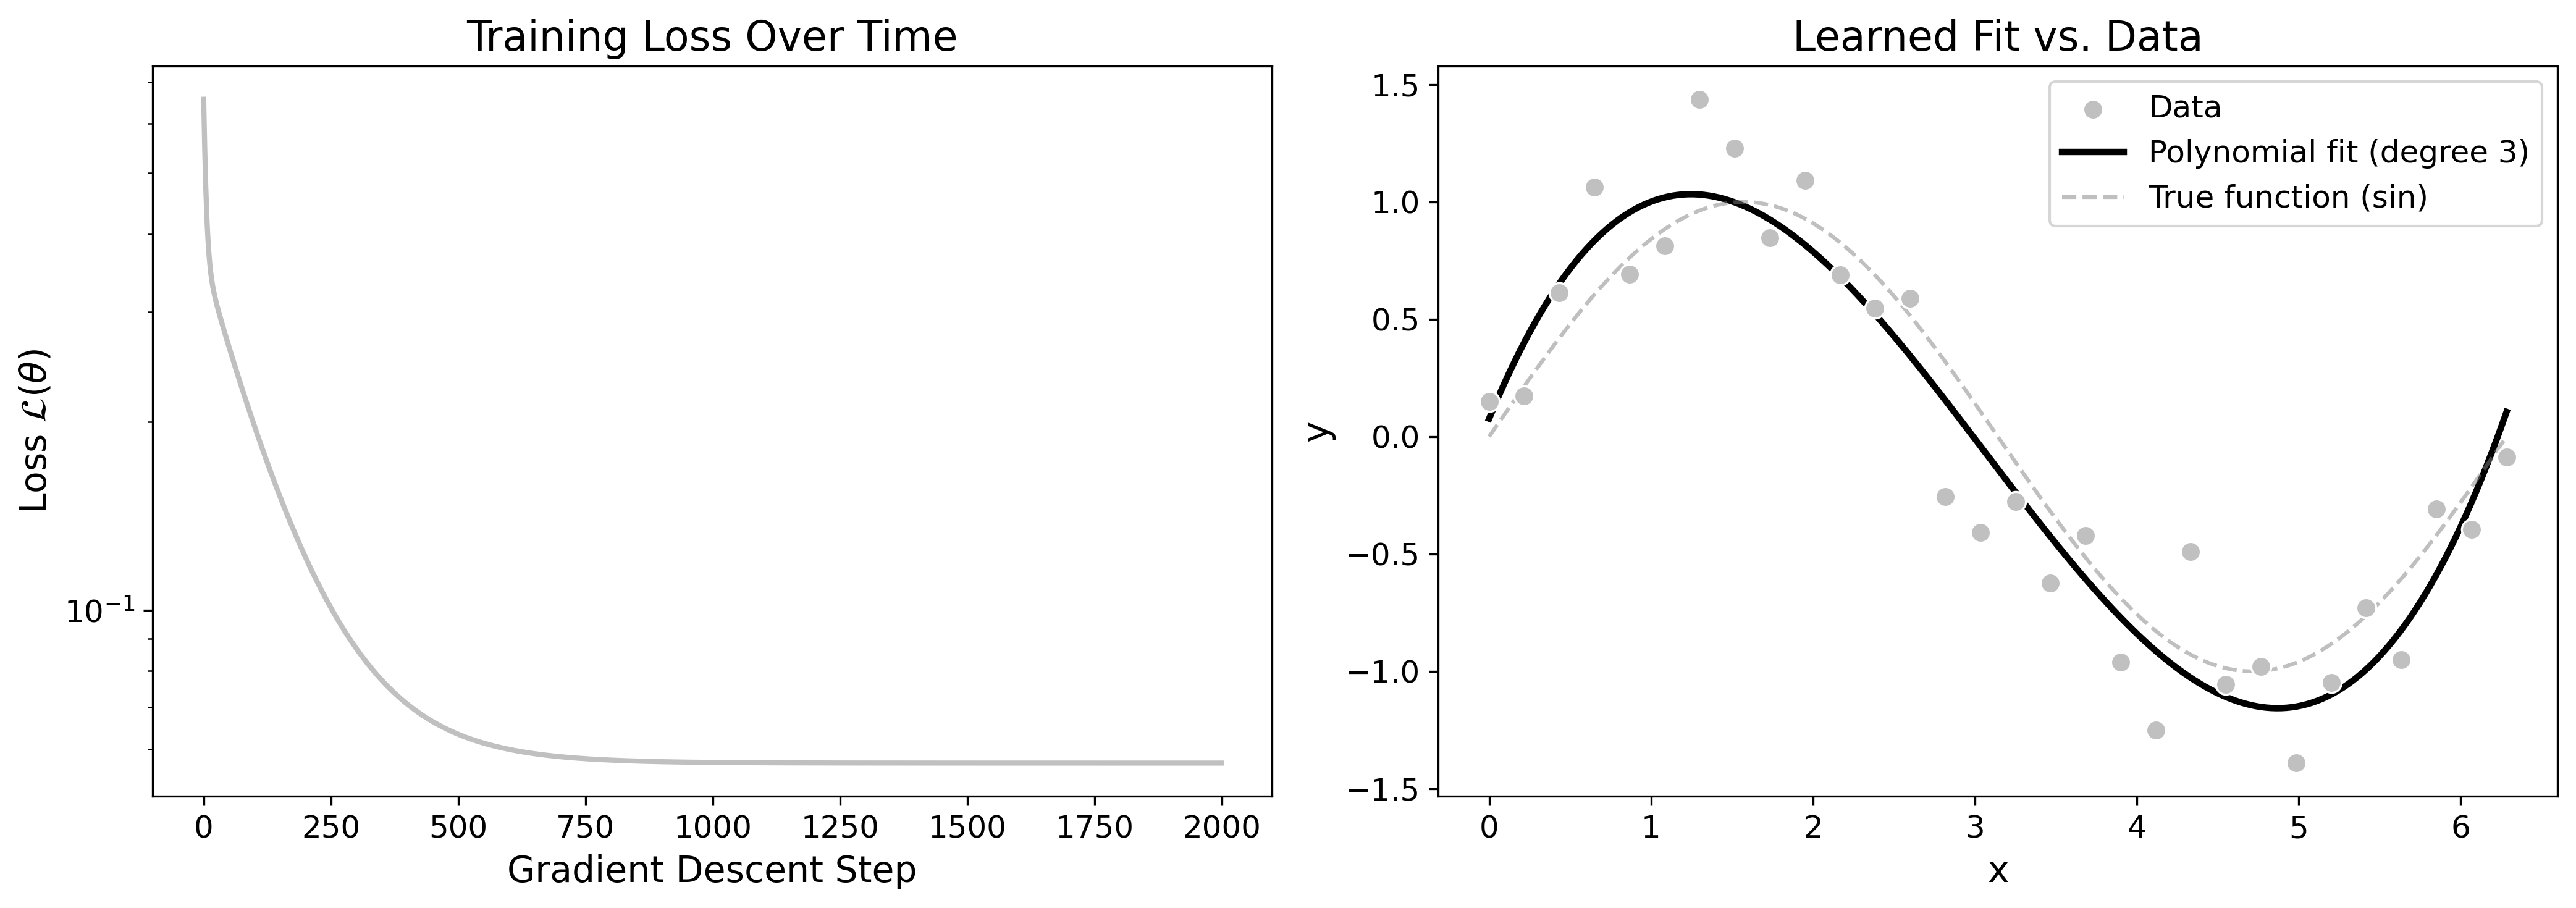

In [20]:
# Visualize: loss curve and fitted polynomial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss curve
axes[0].plot(losses, color='silver', linewidth=2)
axes[0].set_xlabel('Gradient Descent Step', fontsize=14)
axes[0].set_ylabel('Loss $\mathcal{L}(\\theta)$', fontsize=14)
axes[0].set_title('Training Loss Over Time', fontsize=16)
axes[0].tick_params(labelsize=12)
axes[0].set_yscale('log')

# Right: data + fit (using normalized x for evaluation)
x_smooth = np.linspace(0, 2*np.pi, 200)
x_smooth_norm = 2 * (x_smooth - x_min_val) / (x_max_val - x_min_val) - 1
params_np = np.array(params)
y_fit = params_np[0] + params_np[1]*x_smooth_norm + params_np[2]*x_smooth_norm**2 + params_np[3]*x_smooth_norm**3

axes[1].scatter(x_data, y_data, color='silver', s=60, edgecolors='white',
               linewidth=0.8, zorder=5, label='Data')
axes[1].plot(x_smooth, y_fit, color='k', linewidth=2.5, label='Polynomial fit (degree 3)')
axes[1].plot(x_smooth, np.sin(x_smooth), color='gray', linewidth=1.5, linestyle='--',
            alpha=0.5, label='True function (sin)')
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('y', fontsize=14)
axes[1].set_title('Learned Fit vs. Data', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=12)

fig.tight_layout()
plt.show()

**What do you notice?** The loss decreases smoothly, gradient descent is sliding down the loss landscape. The polynomial captures the overall trend of the data, but a degree-3 polynomial can only do so much against a sine wave.

Notice that we never wrote a gradient formula. We just wrote the loss function in Python, and `jax.grad` did all the calculus for us.

#### Quick aside: `jax.jit` makes things fast

When we wrote `jax.jit(jax.grad(mse_loss))`, the `jit` part compiles the gradient function. Let's see the speedup:

In [21]:
import time

grad_no_jit = jax.grad(mse_loss)
grad_with_jit = jax.jit(jax.grad(mse_loss))

test_params = jnp.zeros(4)

# Warm up JIT (first call triggers compilation)
_ = grad_with_jit(test_params, x_data_jax, y_data_jax)

# Time without JIT
n_calls = 1000
start = time.time()
for _ in range(n_calls):
    _ = grad_no_jit(test_params, x_data_jax, y_data_jax)
time_no_jit = time.time() - start

# Time with JIT
start = time.time()
for _ in range(n_calls):
    _ = grad_with_jit(test_params, x_data_jax, y_data_jax)
time_with_jit = time.time() - start

print(f"Without JIT: {time_no_jit:.3f} s for {n_calls} gradient evaluations")
print(f"With JIT:    {time_with_jit:.3f} s for {n_calls} gradient evaluations")
print(f"Speedup:     {time_no_jit / time_with_jit:.1f}x")

Without JIT: 12.067 s for 1000 gradient evaluations
With JIT:    0.026 s for 1000 gradient evaluations
Speedup:     467.1x


---

## Section 3: The ML Recipe

Let's step back and see what we have learned. Every machine learning problem follows the same four-step recipe:

---

> **The Machine Learning Recipe**
>
> 1. **Define a model**: a flexible function with adjustable parameters $\theta$.
>    *(polynomial, image model, neural network, ...)*
>
> 2. **Define a loss function** : a single number that measures how wrong the model is.
>    *(MSE, cross-entropy, likelihood, ...)*
>
> 3. **Compute gradients** : find which direction to adjust each parameter.
>    *(`jax.grad` does this automatically!)*
>
> 4. **Update parameters** : take a step downhill in the loss landscape.
>    *(gradient descent: $\theta \leftarrow \theta - \alpha \nabla \mathcal{L}$)*

---

This same recipe works for:

- Fitting curves to data (what we just did)
- Classifying galaxies from images
- Reconstructing images from noisy measurements
- Training neural networks with billions of parameters
- ...and much more

The only things that change are the *model* and the *loss function*. The optimization machinery stays the same.

**Next up:** we will use this exact recipe to reconstruct an image of a black hole from sparse, noisy measurements.